# Car Price Prediction with Machine Learning

Predict the selling price of a used car using features such as brand, car age, mileage, fuel type, and transmission.


In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# Find and load the car dataset

import os
import glob
import pandas as pd

print("Current folder:", os.getcwd())

# Search for CSV files inside the project
csv_files = glob.glob("../**/*.csv", recursive=True)

print("CSV files found:")
for file in csv_files:
    print(file)

if not csv_files:
    raise FileNotFoundError("CSV file not found. Check that the CSV is inside the dataset folder.")

# Load the dataset
df = pd.read_csv(csv_files[0])

print("\nDataset loaded successfully!")
print("Rows and columns:", df.shape)

df.head()

Current folder: c:\Users\pakki\OneDrive\Desktop\Car-price-prediction\notebook
CSV files found:
..\dataset\archive\car data.csv
..\dataset\archive\CAR DETAILS FROM CAR DEKHO.csv
..\dataset\archive\Car details v3.csv
..\dataset\archive\car details v4.csv

Dataset loaded successfully!
Rows and columns: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
# Data Cleaning

# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows before cleaning:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Clean categorical columns
categorical_columns = ["Fuel_Type", "Seller_Type", "Transmission", "Owner"]

for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip()

# Standardize text values
df["Fuel_Type"] = df["Fuel_Type"].str.title()
df["Seller_Type"] = df["Seller_Type"].str.title()
df["Transmission"] = df["Transmission"].str.title()
df["Owner"] = df["Owner"].str.title()

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:", df.duplicated().sum())

print("\nDataset shape after cleaning:", df.shape)

Missing values before cleaning:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicate rows before cleaning: 2

Missing values after cleaning:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicate rows after cleaning: 0

Dataset shape after cleaning: (299, 9)


In [7]:
# Feature Engineering

# Create car age using the current year
current_year = 2026
df["Car_Age"] = current_year - df["Year"]

# Extract the car brand from the car name
df["Brand"] = df["Car_Name"].str.split().str[0]

# Display the new features
print("Feature engineering completed.")

print("\nNew features:")
print(df[["Car_Name", "Year", "Car_Age", "Brand"]].head(10))

Feature engineering completed.

New features:
        Car_Name  Year  Car_Age   Brand
0           ritz  2014       12    ritz
1            sx4  2013       13     sx4
2           ciaz  2017        9    ciaz
3        wagon r  2011       15   wagon
4          swift  2014       12   swift
5  vitara brezza  2018        8  vitara
6           ciaz  2015       11    ciaz
7        s cross  2015       11       s
8           ciaz  2016       10    ciaz
9           ciaz  2015       11    ciaz


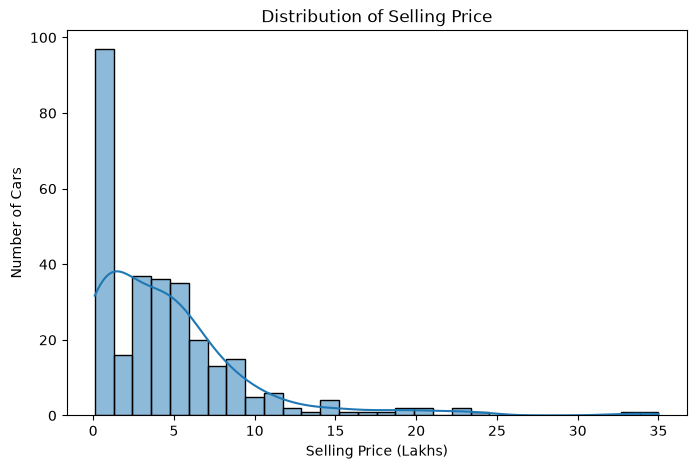

In [8]:
# EDA: Selling Price Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df["Selling_Price"], bins=30, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")
plt.show()

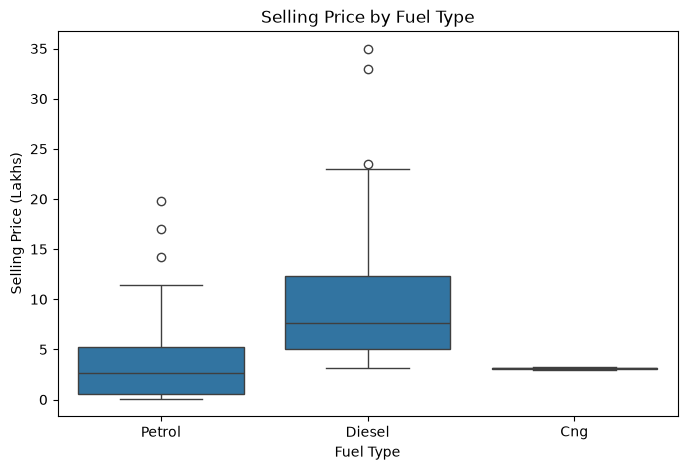

In [9]:
# EDA: Selling Price vs Fuel Type

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price")
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Lakhs)")
plt.show()

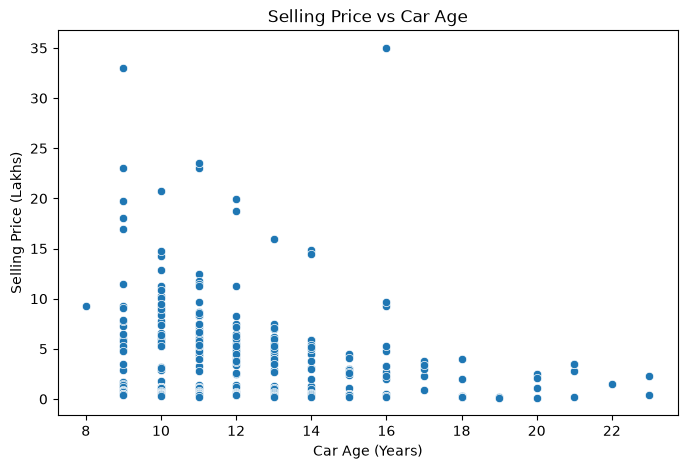

In [10]:
# EDA: Selling Price vs Car Age

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Car_Age", y="Selling_Price")
plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (Lakhs)")
plt.show()

In [11]:
# Encode categorical variables for correlation analysis

df_encoded = df.copy()

categorical_columns = ["Fuel_Type", "Seller_Type", "Transmission", "Owner", "Brand"]

df_encoded = pd.get_dummies(
    df_encoded,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

# Remove text column that is not useful for correlation
df_encoded = df_encoded.drop(columns=["Car_Name"])

print("Categorical encoding completed.")
print("Encoded dataset shape:", df_encoded.shape)

df_encoded.head()

Categorical encoding completed.
Encoded dataset shape: (299, 54)


,Year,Selling_Price,Present_Price,Kms_Driven,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Owner_1,...,Brand_land,Brand_omni,Brand_ritz,Brand_s,Brand_swift,Brand_sx4,Brand_verna,Brand_vitara,Brand_wagon,Brand_xcent
0,2014,3.35,5.59,27000,12,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1,2013,4.75,9.54,43000,13,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,2017,7.25,9.85,6900,9,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,2011,2.85,4.15,5200,15,0,1,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,2014,4.60,6.87,42450,12,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0


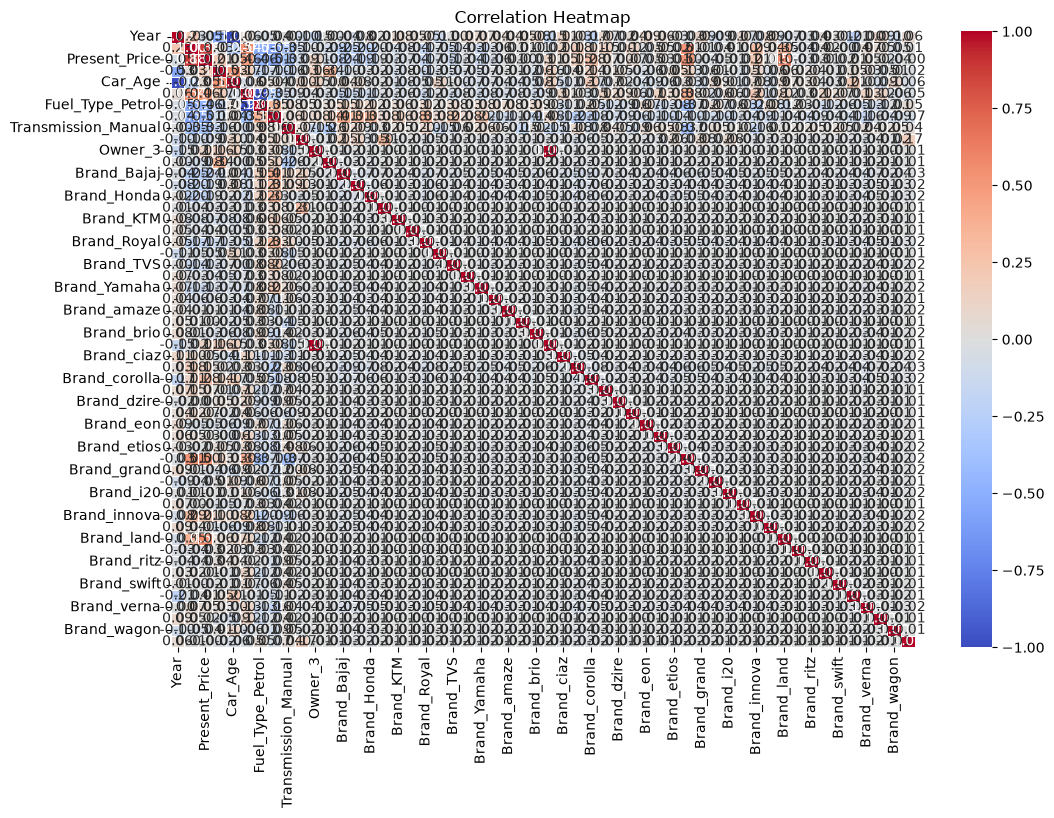

In [12]:
# Correlation Heatmap

correlation_matrix = df_encoded.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [13]:
# Prepare features and target variable

X = df_encoded.drop(columns=["Selling_Price"])
y = df_encoded["Selling_Price"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (239, 53)
Testing data shape: (60, 53)


In [14]:
# Model 1: Linear Regression

linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions
linear_predictions = linear_model.predict(X_test)

# Evaluate the model
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {linear_mae:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"R²   : {linear_r2:.4f}")

Linear Regression Results
-------------------------
MAE  : 1.3522
RMSE : 2.4890
R²   : 0.7596


In [15]:
# Model 2: Random Forest Regression

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
rf_predictions = random_forest_model.predict(X_test)

# Evaluate the model
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Regression Results")
print("--------------------------------")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Regression Results
--------------------------------
MAE  : 1.4778
RMSE : 3.6589
R²   : 0.4806


In [16]:
# Compare the regression models

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2": [linear_r2, rf_r2]
})

print("Model Comparison:")
display(results)

# Select the best model based on R²
best_model_name = results.loc[results["R2"].idxmax(), "Model"]

print(f"\nBest Model: {best_model_name}")

Model Comparison:


,Model,MAE,RMSE,R2
0,Linear Regression,1.352202,2.489029,0.759624
1,Random Forest,1.477760,3.658878,0.480571



Best Model: Linear Regression


Feature Importance - Linear Regression


,Feature,Importance
10,Brand_Activa,3.965389e+00
41,Brand_innova,3.924409e+00
30,Brand_creta,3.746912e+00
43,Brand_land,2.784322e+00
32,Brand_elantra,2.491391e+00
20,Brand_UM,2.431287e+00
36,Brand_fortuner,2.188434e+00
15,Brand_KTM,2.108506e+00
21,Brand_Yamaha,2.010861e+00
13,Brand_Honda,2.002460e+00


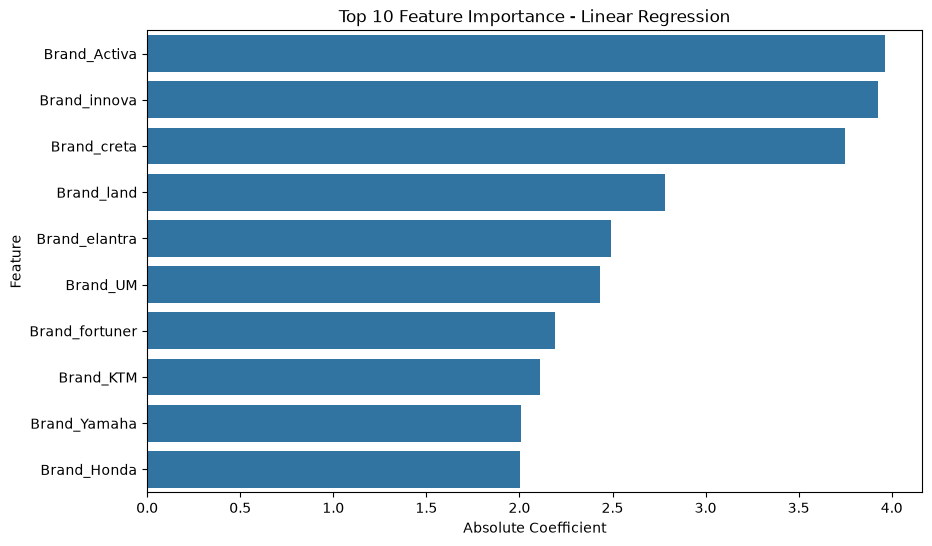

In [17]:
# Feature Importance for the Best Model
# For Linear Regression, absolute coefficient values show feature importance.

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": np.abs(linear_model.coef_)
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top features
print("Feature Importance - Linear Regression")
display(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance - Linear Regression")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.show()

In [ ]:
# Save the Best Model

import joblib
import os

# Create model folder if it does not exist
os.makedirs("../model", exist_ok=True)

# Save the trained Linear Regression model
joblib.dump(linear_model, "../model/car_price_model.pkl")

# Save the feature columns used by the model
joblib.dump(X_train.columns.tolist(), "../model/feature_columns.pkl")

print("Best model saved successfully!")
print("Model: Linear Regression")
print("Saved files:")
print("- car_price_model.pkl")
print("- feature_columns.pkl")
